# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

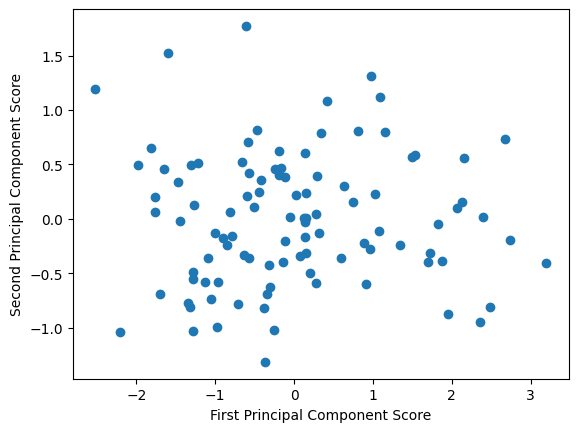

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

The 3 outliers in the upper left corner of the scatter plot have low first principal component scores and high second principal component scores. Since `series_3` have the lowest PC1, this means that the observations have low values in `series_3`. `Series_1` and `series_2` have positive contribution for PC2 and `series_3` have negative contribution. This means that the outliers corresponding to the observations where `series_3` is unsually low is where `series_1` and `series_2` are relatively higher.

It's easier to draw conclusions about `series_3` because it has a greater variability compared to the other two series. `Series_2` has similar moderate variation, with slight noise, as `series_1`, so they are correlated. Because `series_1` and `series_2` are so strongly correlated, PCA effectively treats them as a single direction, and their small differences contribute very little to the total variance. This makes it difficult to distinguish between them in the PCA plot.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [28]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import math
import kagglehub
import os
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

### *Reading in the Dataset:*

In [4]:
# Download latest version
path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")

files = os.listdir(path)
df_file = files[0]

df = pd.read_csv(os.path.join(path, df_file))
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


### *Heatmap: Diabetes Status by Income and Education*

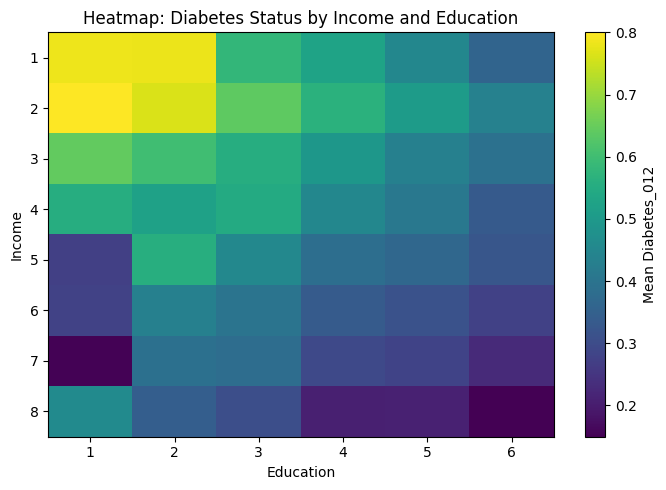

In [18]:
heatmap = df.pivot_table(
    index="Income",
    columns="Education",
    values="Diabetes_012",
    aggfunc="mean"
)

plt.figure(figsize=(7, 5))
plt.imshow(heatmap, aspect="auto")
plt.colorbar(label="Mean Diabetes_012")
plt.xticks(range(len(heatmap.columns)), [int(c) for c in heatmap.columns])
plt.yticks(range(len(heatmap.index)), [int(i) for i in heatmap.index])
plt.xlabel("Education")
plt.ylabel("Income")
plt.title("Heatmap: Diabetes Status by Income and Education")
plt.tight_layout()
plt.show()

In [19]:
heatmap

Education,1.0,2.0,3.0,4.0,5.0,6.0
Income,,,,,,
1.0,0.783784,0.781111,0.580078,0.526433,0.450144,0.358072
2.0,0.800000,0.762483,0.638908,0.565857,0.506486,0.435599
3.0,0.642857,0.600000,0.555881,0.493780,0.431818,0.391119
4.0,0.555556,0.522314,0.548520,0.449994,0.409826,0.334677
5.0,0.272727,0.558577,0.452681,0.385806,0.367992,0.323729
6.0,0.277778,0.433447,0.400651,0.336737,0.312354,0.276556
7.0,0.153846,0.388889,0.381356,0.292773,0.280269,0.227549
8.0,0.461538,0.345070,0.305970,0.207057,0.209080,0.149735


If we look at the heatmap and its values, it strongly suggests a clear pattern where average diabetes status tends to be higher among individuals with lower income and lower education levels. This indicates a strong association between socioeconomic factors and diabetes outcomes.

With that said, it's important to make the distinction that this heatmap only shows correlation and not causation. There are other factors such as age, general health, access to healthcare that could play a big role in explaining these patterns.

### *Bubble Plot: Diabetes Status by Age and General Health*

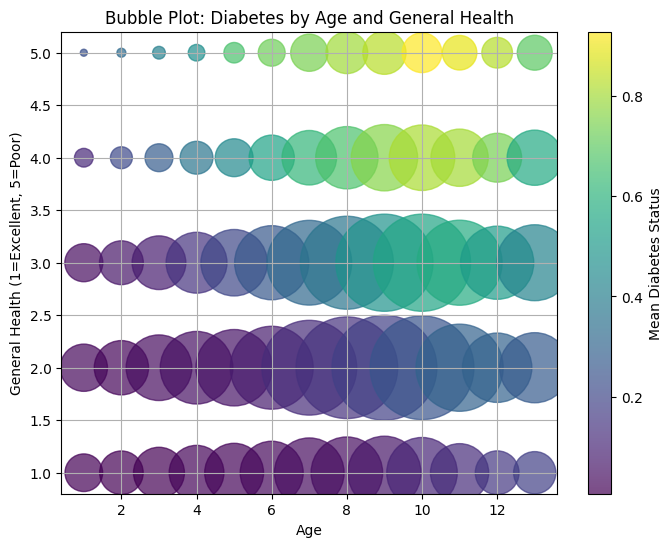

In [20]:
bubble_df = df.groupby(['Age', 'GenHlth']).agg(
    mean_diabetes=('Diabetes_012', 'mean'),
    count=('Diabetes_012', 'size')
).reset_index()

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    bubble_df['Age'],
    bubble_df['GenHlth'],
    s=bubble_df['count'] * 0.5,
    c=bubble_df['mean_diabetes'],
    cmap='viridis',
    alpha=0.7
)

plt.colorbar(scatter, label='Mean Diabetes Status')
plt.xlabel('Age')
plt.ylabel('General Health (1=Excellent, 5=Poor)')
plt.title('Bubble Plot: Diabetes by Age and General Health')

plt.grid(True)
plt.show()

This bubble plot indicate a clear pattern where diabetes tends to be more prevelant as age increases and general health worsen. Larger bubbles mean that many indivudals fall into the middle age and moderate health categories. The bubble sizes help highlight which groups contribute most to the overall population, showing that moderate risk groups may represent a larger share of individuals than the highest risk groups.

### *PCA*

In [33]:
X = df.select_dtypes(include=['float64', 'int64'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA
pca = PCA()
pca.fit(X)

# Explained variance ratios
print(pca.explained_variance_ratio_)

variance_captured = pca.explained_variance_ratio_[0]
print("Variance captured by PC1:", variance_captured)

[4.81585829e-01 2.19842063e-01 2.10714890e-01 4.77471072e-02
 2.08998442e-02 4.29308880e-03 3.45743858e-03 2.11250379e-03
 1.48032885e-03 1.20688561e-03 1.16046051e-03 1.09574764e-03
 8.60310492e-04 8.12524175e-04 6.53859074e-04 4.78514553e-04
 3.84154104e-04 3.77609686e-04 2.66834150e-04 2.13044976e-04
 1.83123210e-04 1.73838095e-04]
Variance captured by PC1: 0.4815858294284675


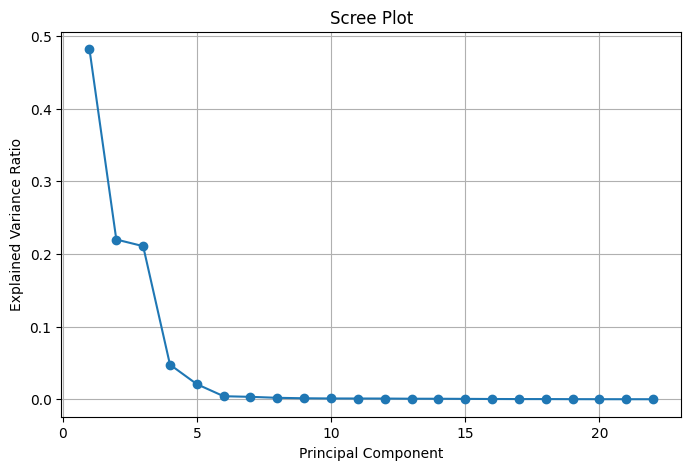

In [34]:
explained = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained)+1), explained, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.grid(True)
plt.show()

The first principal component explains about 48% of the differences in the data, so it shows a lot, but not all, of the important patterns. The second and third components also explain a big part of the data (around 22% and 21%), so together the first three components cover over 90% of the variation. This means the data is mostly 3-D. Using just the first component gives a quick 1-D summary, but it leaves out more than half of the information. To fully understand the data, you need to include the second and third components as well.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

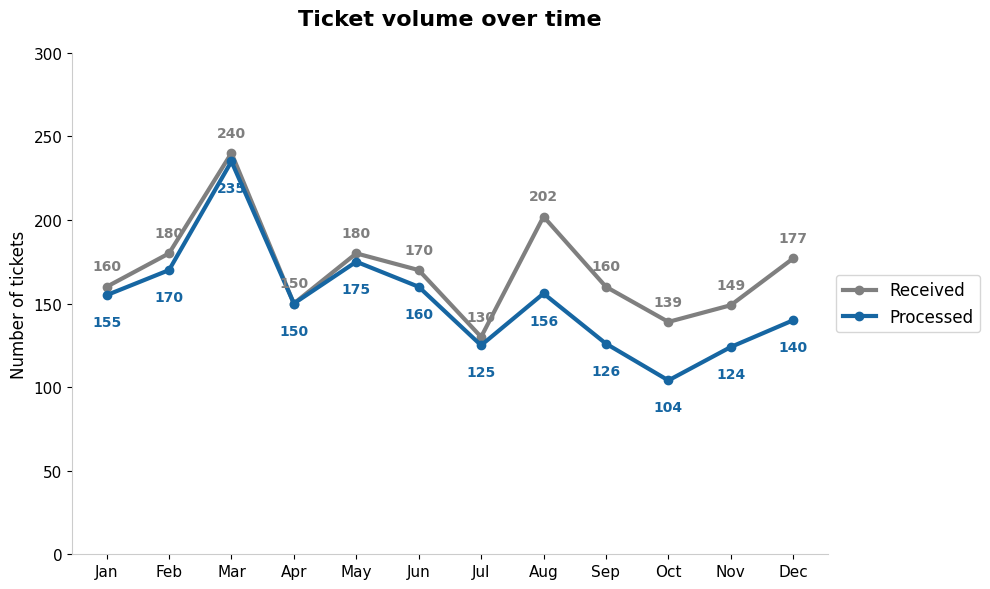

In [36]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
received = [160, 180, 240, 150, 180, 170, 130, 202, 160, 139, 149, 177]
processed = [155, 170, 235, 150, 175, 160, 125, 156, 126, 104, 124, 140]

# Plot both series
plt.figure(figsize=(10, 6))
plt.plot(months, received, color='#7F7F7F', linewidth=3, marker='o', markersize=6)
plt.plot(months, processed, color='#1666A2', linewidth=3, marker='o', markersize=6)

# Add data labels for each point
for x, y in zip(months, received):
    plt.text(x, y + 8, str(y), ha='center', va='bottom', color='#7F7F7F', fontsize=10, fontweight='bold')
for x, y in zip(months, processed):
    plt.text(x, y - 12, str(y), ha='center', va='top', color='#1666A2', fontsize=10, fontweight='bold')

# Styling
plt.title('Ticket volume over time', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Number of tickets', fontsize=12)
plt.ylim(0, 300)
plt.grid(False)

# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

plt.legend(['Received', 'Processed'], loc='center left', bbox_to_anchor=(1, 0.5), 
          fontsize=12)

# Set x-axis labels
plt.xticks(months, fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()